# Modelo Preditivo de Classificação de NPS

Para um modelo de classificação precisamos transformar a variável target numérica `nps_score` em uma variável categórica.
Podemos utilizar tanto a classificação multiclasse já conhecida do NPS como `Promoter`, `Passive`, `Detractor`, ou também podemos simplificar para uma classificação binária `Satisfied` = [`Promoter`, `Passive`] e `Unsatisfied` = [`Detractor`].
Iremos treinar e testar ambas classificações.

In [5]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('../data/desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## Transformação de Variáveis Target

In [ ]:
# Classificação NPS em 3 classes:
def classify_3_nps(score):
    if score >= 9:
        return 'Promoter'
    elif score >= 7:
        return 'Passive'
    return 'Detractor'

# Classificação NPS em 2 classes:
def classify_2_nps(score):
    if score >= 7:
        return 'Satisfied'
    return 'Unsatisfied'

df['nps_class_3'] = df['nps_score'].apply(classify_3_nps)
df['nps_class_2'] = df['nps_score'].apply(classify_2_nps)
df[['nps_score', 'nps_class_3', 'nps_class_2']]

,nps_score,nps_class_3,nps_class_2
0,6.9,Detractor,Unsatisfied
1,2.4,Detractor,Unsatisfied
2,4.8,Detractor,Unsatisfied
3,5.9,Detractor,Unsatisfied
4,6.1,Detractor,Unsatisfied
...,...,...,...
2495,3.7,Detractor,Unsatisfied
2496,3.7,Detractor,Unsatisfied
2497,7.4,Passive,Satisfied
2498,2.3,Detractor,Unsatisfied


## Seleção e Sepração de Dados

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report

# Configuração de validação cruzada compartilhada para todos os modelos
shared_cv = KFold(n_splits=10, shuffle=True, random_state=42)

# One Hot Encode a coluna 'customer_region'
one_hot_encoded_regions = pd.get_dummies(df['customer_region'], prefix='region', drop_first=True)

# Features de treinamento
X = df.drop(columns=[
    'customer_id',
    'order_id',
    'customer_region',
    'nps_score',
    'nps_class_3',
    'nps_class_2'])

# Join das features com as colunas one-hot encoded
X = X.join(one_hot_encoded_regions)

y2 = df['nps_class_2'] # Labels resultado binário
y3 = df['nps_class_3'] # Labels resultado 3 classes

# Divisão dos dados em treino e teste para ambos os conjuntos de labels
X2_train, X2_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.3, random_state=42)
X3_train, X3_test, y3_train, y3_test = train_test_split(X, y3, test_size=0.3, random_state=42)

# Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

lr2 = LogisticRegression()
lr3 = LogisticRegression()

lr2.fit(X2_train, y2_train)
lr3.fit(X3_train, y3_train)

lr2_predictions = lr2.predict(X2_test)
lr3_predictions = lr3.predict(X3_test)

print("=== RESULTADOS: MODELO 2 CATEGORIAS (Insatisfeito vs Satisfeito) ===")
print(classification_report(y2_test, lr2_predictions))
print("=== RESULTADOS: MODELO 3 CATEGORIAS (Insatisfeito vs Neutro vs Satisfeito) ===")
print(classification_report(y3_test, lr3_predictions))

=== RESULTADOS: MODELO 2 CATEGORIAS (Insatisfeito vs Satisfeito) ===
              precision    recall  f1-score   support

   Satisfied       0.69      0.38      0.49       122
 Unsatisfied       0.89      0.97      0.93       628

    accuracy                           0.87       750
   macro avg       0.79      0.67      0.71       750
weighted avg       0.86      0.87      0.85       750

=== RESULTADOS: MODELO 3 CATEGORIAS (Insatisfeito vs Neutro vs Satisfeito) ===
              precision    recall  f1-score   support

   Detractor       0.87      0.98      0.92       628
     Passive       0.38      0.16      0.22        88
    Promoter       0.00      0.00      0.00        34

    accuracy                           0.84       750
   macro avg       0.41      0.38      0.38       750
weighted avg       0.77      0.84      0.80       750



# Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

rfc2 = RandomForestClassifier()
rfc3 = RandomForestClassifier()

rfc2.fit(X2_train, y2_train)
rfc3.fit(X3_train, y3_train)

rfc2_predictions = rfc2.predict(X2_test)
rfc3_predictions = rfc3.predict(X3_test)

print("=== RESULTADOS: MODELO 2 CATEGORIAS (Insatisfeito vs Satisfeito) ===")
print(classification_report(y2_test, rfc2_predictions))
print("=== RESULTADOS: MODELO 3 CATEGORIAS (Insatisfeito vs Neutro vs Satisfeito) ===")
print(classification_report(y3_test, rfc3_predictions))

=== RESULTADOS: MODELO 2 CATEGORIAS (Insatisfeito vs Satisfeito) ===
              precision    recall  f1-score   support

   Satisfied       0.95      0.61      0.74       122
 Unsatisfied       0.93      0.99      0.96       628

    accuracy                           0.93       750
   macro avg       0.94      0.80      0.85       750
weighted avg       0.93      0.93      0.92       750

=== RESULTADOS: MODELO 3 CATEGORIAS (Insatisfeito vs Neutro vs Satisfeito) ===
              precision    recall  f1-score   support

   Detractor       0.93      0.99      0.96       628
     Passive       0.46      0.22      0.29        88
    Promoter       0.46      0.47      0.46        34

    accuracy                           0.88       750
   macro avg       0.62      0.56      0.57       750
weighted avg       0.85      0.88      0.86       750



## Metrificação

lr2: mean=0.8886, std=0.0271
lr3: mean=0.8526, std=0.0253
rfc2: mean=0.9274, std=0.0140
rfc3: mean=0.8949, std=0.0245
=== LogisticRegression ===
              precision    recall  f1-score   support

   Satisfied     0.6866    0.3770    0.4868       122
 Unsatisfied     0.8887    0.9666    0.9260       628

    accuracy                         0.8707       750
   macro avg     0.7876    0.6718    0.7064       750
weighted avg     0.8558    0.8707    0.8546       750

ROC AUC: 0.0978
=== RandomForestClassifier ===
              precision    recall  f1-score   support

   Satisfied     0.9231    0.5902    0.7200       122
 Unsatisfied     0.9256    0.9904    0.9569       628

    accuracy                         0.9253       750
   macro avg     0.9243    0.7903    0.8385       750
weighted avg     0.9252    0.9253    0.9184       750

ROC AUC: 0.0782
=== LogisticRegression ===
              precision    recall  f1-score   support

   Detractor     0.8666    0.9825    0.9209       628
  

,model,cv_mean,cv_std,accuracy,f1_macro
1,rfc2,0.927429,0.014009,0.926667,0.842014
0,lr2,0.888571,0.027075,0.870667,0.706392
3,rfc3,0.894857,0.024538,0.878667,0.570326
2,lr3,0.852571,0.025272,0.841333,0.381632


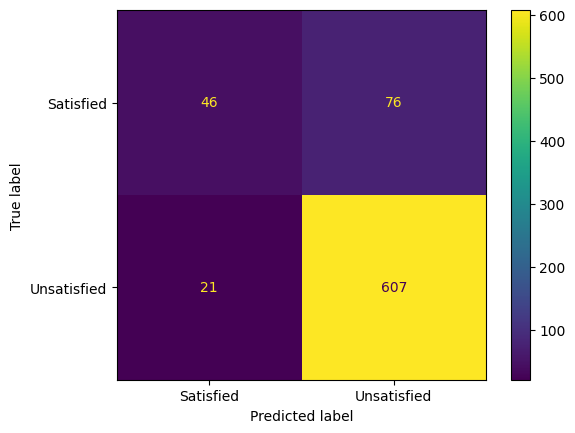

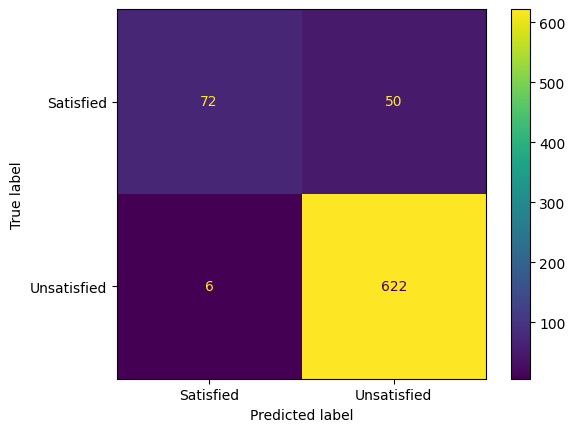

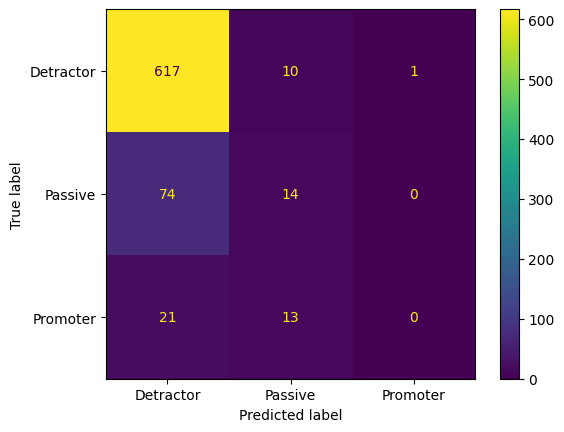

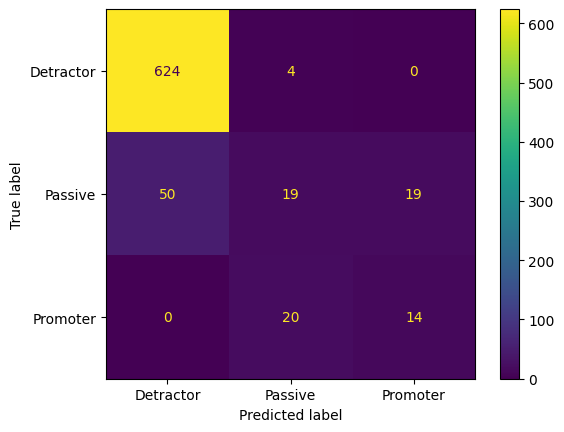

In [ ]:
# Código Gemini, extrair oq for importante

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# 1) Resumo dos cross-val já computados
cv_summary = {
    'lr2': lr2_scores,
    'lr3': lr3_scores,
    'rfc2': rfc2_scores,
    'rfc3': rfc3_scores
}
for name, scores in cv_summary.items():
    print(f"{name}: mean={np.mean(scores):.4f}, std={np.std(scores):.4f}")

# 2) Função de avaliação no hold-out (treino/test já existem: X2_train/X2_test, y2_train/y2_test, X3_train/...)
def evaluate_and_report(model, X_train, X_test, y_train, y_test, problem='binary', positive_label=None):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("===", model.__class__.__name__, "===")
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test)).plot()
    if problem == 'binary' and hasattr(model, "predict_proba"):
        # definir label positivo (ex: 'Satisfied') se necessário
        y_true_bin = (y_test == positive_label).astype(int) if positive_label is not None else (y_test.astype('category').cat.codes)
        y_score = model.predict_proba(X_test)[:, 1]
        try:
            auc = roc_auc_score(y_true_bin, y_score)
            print("ROC AUC:", round(auc,4))
        except Exception:
            pass

# 3) Avaliar os 4 modelos com as bases apropriadas
# Modelos binários usam X2_train/X2_test, multiclasses X3_train/X3_test
evaluate_and_report(lr2, X2_train, X2_test, y2_train, y2_test, problem='binary', positive_label='Satisfied')
evaluate_and_report(rfc2, X2_train, X2_test, y2_train, y2_test, problem='binary', positive_label='Satisfied')
evaluate_and_report(lr3, X3_train, X3_test, y3_train, y3_test, problem='multiclass')
evaluate_and_report(rfc3, X3_train, X3_test, y3_train, y3_test, problem='multiclass')

# 4) Construir tabela resumida de métricas (exemplo com F1-macro e Acurácia)
from sklearn.metrics import f1_score, accuracy_score
rows = []
for name, (model, _scores) in [('lr2',(lr2,lr2_scores)), ('rfc2',(rfc2,rfc2_scores)), ('lr3',(lr3,lr3_scores)), ('rfc3',(rfc3,rfc3_scores))]:
    # escolher X/y conforme nome
    if name.endswith('2'):
        Xtr,Xte,ytr,yte = X2_train, X2_test, y2_train, y2_test
    else:
        Xtr,Xte,ytr,yte = X3_train, X3_test, y3_train, y3_test
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    rows.append({
        'model': name,
        'cv_mean': np.mean(_scores),
        'cv_std': np.std(_scores),
        'accuracy': accuracy_score(yte, preds),
        'f1_macro': f1_score(yte, preds, average='macro')
    })
summary_df = pd.DataFrame(rows).sort_values('f1_macro', ascending=False)
display(summary_df)